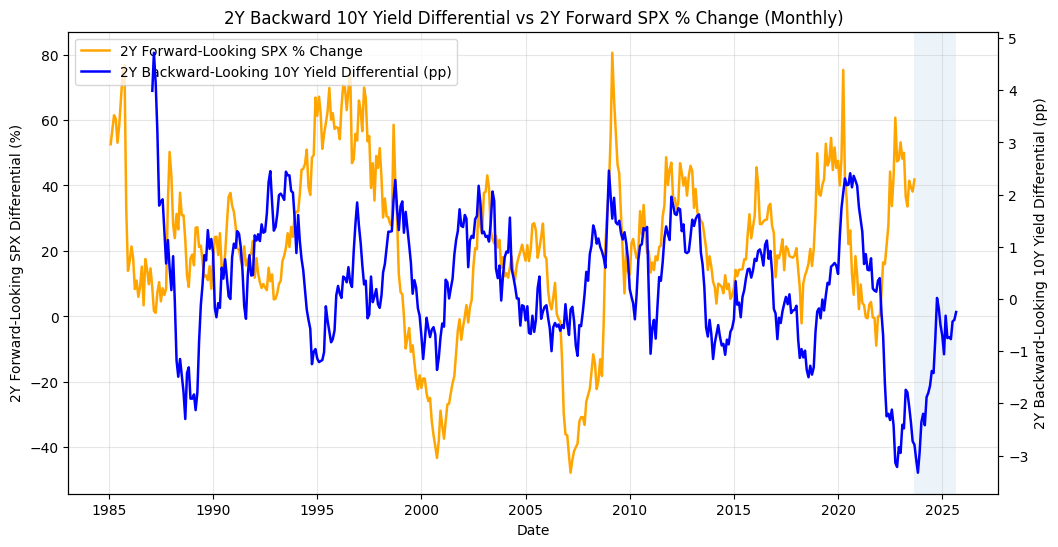

Blue series (yields) through: 2025-08-31
Orange series (forward SPX) through: 2023-08-31  (stops ~24m earlier by construction)


In [1]:
# pip install yfinance pandas_datareader matplotlib pandas numpy

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas_datareader.data as pdr
import yfinance as yf

def _force_series(x, name):
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    x = pd.Series(x)
    x.name = name
    return x.astype(float)

def load_monthly(start='1985-01-01'):
    y10 = pdr.DataReader('DGS10', 'fred', start=start)
    y10 = _force_series(y10, 'DGS10_pct').resample('ME').last()

    spx_raw = yf.download('^GSPC', start=start, progress=False, auto_adjust=True)
    spx = _force_series(spx_raw['Close'], 'SPX').resample('ME').last()

    return spx, y10

spx, y10 = load_monthly()

spx_fwd_24m = (spx.shift(-24) / spx - 1.0).rename('SPX_fwd_24m_pct')    
y10_back_24m = (y10.shift(24) - y10).rename('DGS10_back_24m_pp')           

last_orange = spx_fwd_24m.dropna().index.max()
last_blue   = y10_back_24m.dropna().index.max()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(spx_fwd_24m.dropna().index,
         spx_fwd_24m.dropna().values * 100.0,
         color='orange', linewidth=1.8,
         label='2Y Forward-Looking SPX % Change')

ax1.set_ylabel('2Y Forward-Looking SPX Differential (%)')
ax1.set_xlabel('Date')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(y10_back_24m.dropna().index,
         y10_back_24m.dropna().values,
         color='blue', linewidth=1.8,
         label='2Y Backward-Looking 10Y Yield Differential (pp)')
ax2.set_ylabel('2Y Backward-Looking 10Y Yield Differential (pp)')

ax1.set_title('2Y Backward 10Y Yield Differential vs 2Y Forward SPX % Change (Monthly)')

if (pd.notna(last_orange)) and (pd.notna(last_blue)) and (last_blue > last_orange):
    ax1.axvspan(last_orange, last_blue, alpha=0.08)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper left')

plt.show()

print(f"Blue series (yields) through: {last_blue.date()}")
print(f"Orange series (forward SPX) through: {last_orange.date()}  (stops ~24m earlier by construction)")